In [2]:
import sys

print(sys.executable)

/Users/surajkumardwivedi/Desktop/Ml/customer_segregation/.venv/bin/python


In [4]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [12]:
X = df[
    [
        "Gender",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [13]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
# X_scaled.head()
X_scaled[:5]

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992]])

In [18]:
type(X)

pandas.DataFrame

In [19]:
type(X_scaled)

numpy.ndarray

In [21]:
X_scaled.mean(axis=0)

array([-7.54951657e-17, -1.02140518e-16, -2.13162821e-16, -1.46549439e-16])

In [22]:
X_scaled.std(axis=0)

array([1., 1., 1., 1.])

In [23]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

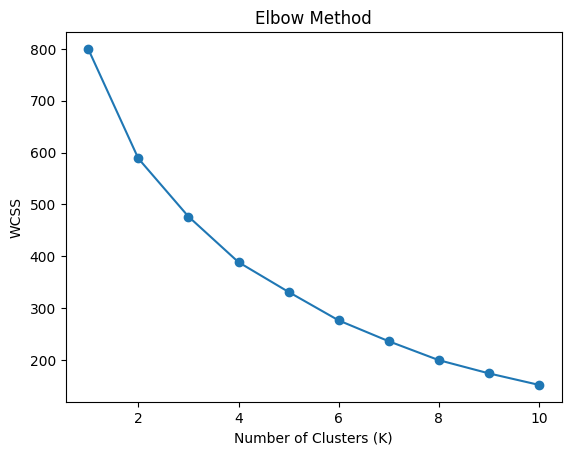

In [24]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [25]:
print(wcss)

[800.0, 588.8026767824937, 476.78755441351586, 388.7178614053845, 331.3098837641086, 276.4117595313096, 236.2049470708688, 199.7504611206557, 174.23547730691476, 152.0298342977569]


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}: {score:.4f}")

K=2: 0.2518
K=3: 0.2595
K=4: 0.2984
K=5: 0.3041
K=6: 0.3311
K=7: 0.3574
K=8: 0.3880
K=9: 0.4031
K=10: 0.4208


In [31]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters_labels = kmeans_final.fit_predict(X_scaled)

df["Cluster"] = clusters_labels

In [32]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,3
1,2,0,21,15,81,3
2,3,1,20,16,6,3
3,4,1,23,16,77,3
4,5,1,31,17,40,3


In [33]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

In [34]:
df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,32.69,86.54,82.13
1,36.48,89.52,18.00
2,49.81,49.23,40.07
3,24.91,39.72,61.20
4,55.71,53.69,36.77


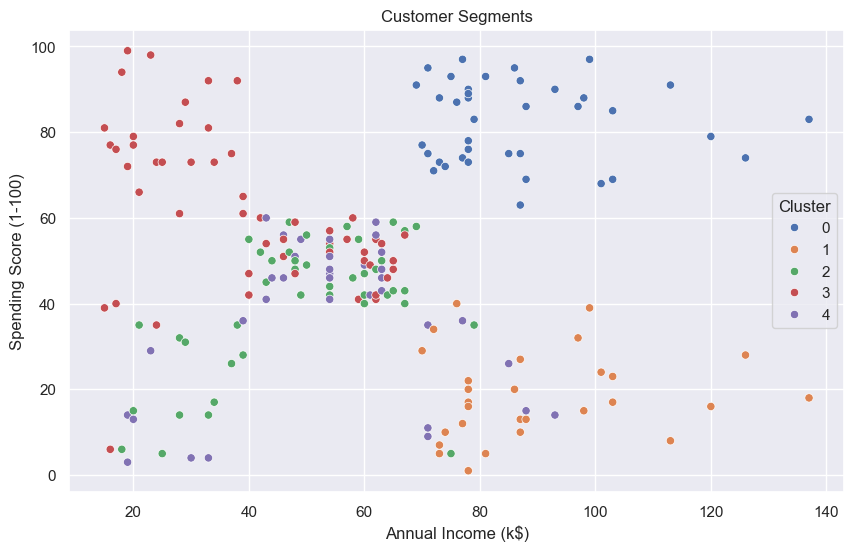

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="deep"
)

plt.title("Customer Segments")
plt.show()

In [37]:
cluster_names = {
    0: "Premium Customers",
    1: "Careful Rich Customers",
    2: "Average Customers",
    3: "Young Spenders",
    4: "Senior Customers"
}

df["Segment"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Segment"]].head()

,Cluster,Segment
0,3,Young Spenders
1,3,Young Spenders
2,3,Young Spenders
3,3,Young Spenders
4,3,Young Spenders


In [38]:
df["Segment"].value_counts()

Segment
Young Spenders            54
Average Customers         43
Premium Customers         39
Senior Customers          35
Careful Rich Customers    29
Name: count, dtype: int64

In [39]:
recommendations = {
    "Premium Customers":
        "Offer VIP memberships, premium products, and exclusive discounts.",

    "Careful Rich Customers":
        "Provide personalized offers and loyalty rewards to increase spending.",

    "Average Customers":
        "Promote regular deals and cross-sell related products.",

    "Young Spenders":
        "Target with trendy products, social media campaigns, and seasonal offers.",

    "Senior Customers":
        "Focus on comfort products, healthcare-related offers, and personalized service."
}

In [40]:
df["Recommendation"] = df["Segment"].map(recommendations)

In [41]:
df[["Segment", "Recommendation"]].head(10)

,Segment,Recommendation
0,Young Spenders,"Target with trendy products, social media camp..."
1,Young Spenders,"Target with trendy products, social media camp..."
2,Young Spenders,"Target with trendy products, social media camp..."
3,Young Spenders,"Target with trendy products, social media camp..."
4,Young Spenders,"Target with trendy products, social media camp..."
5,Young Spenders,"Target with trendy products, social media camp..."
6,Average Customers,Promote regular deals and cross-sell related p...
7,Young Spenders,"Target with trendy products, social media camp..."
8,Senior Customers,"Focus on comfort products, healthcare-related ..."
9,Young Spenders,"Target with trendy products, social media camp..."


In [42]:
import joblib

In [46]:
joblib.dump(kmeans_final, "kmeans_model.pkl")

['kmeans_model.pkl']

In [47]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [48]:
import os

print(os.path.exists("kmeans_model.pkl"))
print(os.path.exists("scaler.pkl"))

True
True


In [52]:
import joblib
import numpy as np

model = joblib.load("kmeans_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

In [53]:
import pandas as pd

new_customer = pd.DataFrame({
    "Gender": [1],
    "Age": [25],
    "Annual Income (k$)": [80],
    "Spending Score (1-100)": [90]
})

In [54]:
new_customer_scaled = scaler_loaded.transform(new_customer)

cluster = model.predict(new_customer_scaled)

print("Predicted Cluster:", cluster[0])

Predicted Cluster: 0


In [56]:
cluster_names = {
    0: "Premium Customers",
    1: "Careful Rich Customers",
    2: "Average Customers",
    3: "Young Spenders",
    4: "Senior Customers"
}

In [57]:
segment = cluster_names[cluster[0]]

print("Segment:", segment)

Segment: Premium Customers


In [58]:
recommendations = {
    "Premium Customers":
        "Offer VIP memberships, premium products, and exclusive discounts.",

    "Careful Rich Customers":
        "Provide personalized offers and loyalty rewards to increase spending.",

    "Average Customers":
        "Promote regular deals and cross-sell related products.",

    "Young Spenders":
        "Target with trendy products, social media campaigns, and seasonal offers.",

    "Senior Customers":
        "Focus on comfort products, healthcare-related offers, and personalized service."
}

In [59]:
print("Segment:", segment)
print("Recommendation:", recommendations[segment])

Segment: Premium Customers
Recommendation: Offer VIP memberships, premium products, and exclusive discounts.


In [60]:
from sklearn.decomposition import PCA

In [61]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

print(pca_features.shape)

(200, 2)


In [62]:
pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = df["Cluster"]

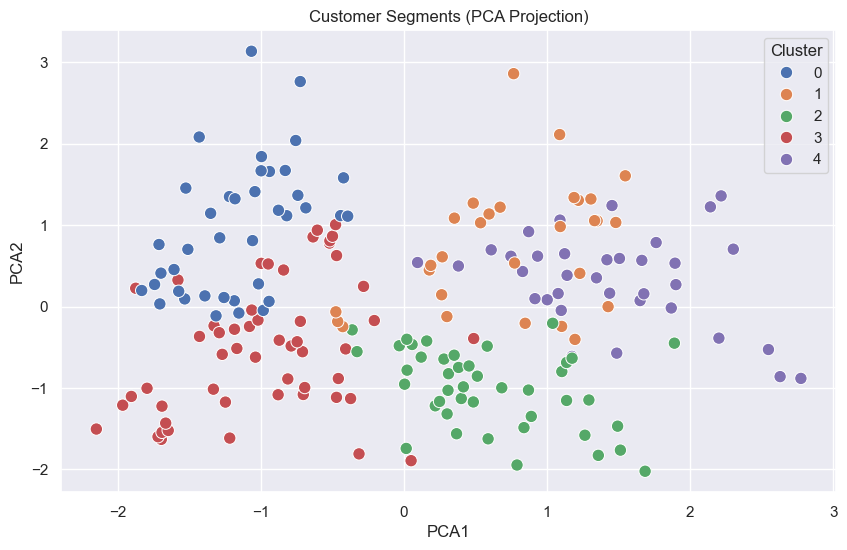

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="deep",
    s=80
)

plt.title("Customer Segments (PCA Projection)")
plt.show()

In [64]:
print(pca.explained_variance_ratio_)
print("Total Variance Explained:",
      pca.explained_variance_ratio_.sum())

[0.33690046 0.26230645]
Total Variance Explained: 0.5992069019819847


In [65]:
cluster_insights = df.groupby("Segment").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

cluster_insights

,Age,Annual Income (k$),Spending Score (1-100)
Segment,,,
Average Customers,49.81,49.23,40.07
Careful Rich Customers,36.48,89.52,18.00
Premium Customers,32.69,86.54,82.13
Senior Customers,55.71,53.69,36.77
Young Spenders,24.91,39.72,61.20


In [68]:
def generate_business_insight(row):

    age = row["Age"]
    income = row["Annual Income (k$)"]
    spending = row["Spending Score (1-100)"]

    if income > 80 and spending > 70:
        return "High-value customers. Prioritize loyalty programs, VIP benefits, and premium products."

    elif income > 80 and spending < 40:
        return "Customers have strong purchasing power but spend cautiously. Use targeted promotions to improve engagement."

    elif age > 50:
        return "Older customers with conservative spending patterns. Focus on trust, service quality, and personalized experiences."

    elif spending > 60:
        return "Active spenders who respond well to marketing campaigns and trend-based products."

    elif income < 60 and spending < 50:
        return "Price-sensitive customers. Focus on discounts, bundles, and value-based offerings."

    else:
        return "Balanced customer segment suitable for broad marketing campaigns."

In [69]:
cluster_insights["Business Insight"] = cluster_insights.apply(
    generate_business_insight,
    axis=1
)

cluster_insights

,Age,Annual Income (k$),Spending Score (1-100),Business Insight
Segment,,,,
Average Customers,49.81,49.23,40.07,"Price-sensitive customers. Focus on discounts,..."
Careful Rich Customers,36.48,89.52,18.00,Customers have strong purchasing power but spe...
Premium Customers,32.69,86.54,82.13,High-value customers. Prioritize loyalty progr...
Senior Customers,55.71,53.69,36.77,Older customers with conservative spending pat...
Young Spenders,24.91,39.72,61.20,Active spenders who respond well to marketing ...


In [70]:
optimal_k = 5

elbow_explanation = f"""
The Elbow Method suggests {optimal_k} customer segments because the reduction in clustering error
starts to slow significantly after K={optimal_k}.

Business Interpretation:
Using fewer than {optimal_k} segments may group together customers with different purchasing behaviors,
while using more than {optimal_k} segments adds unnecessary complexity without providing meaningful business value.
"""

print(elbow_explanation)


The Elbow Method suggests 5 customer segments because the reduction in clustering error
starts to slow significantly after K=5.

Business Interpretation:
Using fewer than 5 segments may group together customers with different purchasing behaviors,
while using more than 5 segments adds unnecessary complexity without providing meaningful business value.

